In [149]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [150]:
!pip install opencv-python

In [151]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow


import numpy as np
import os
import matplotlib.pyplot as plt

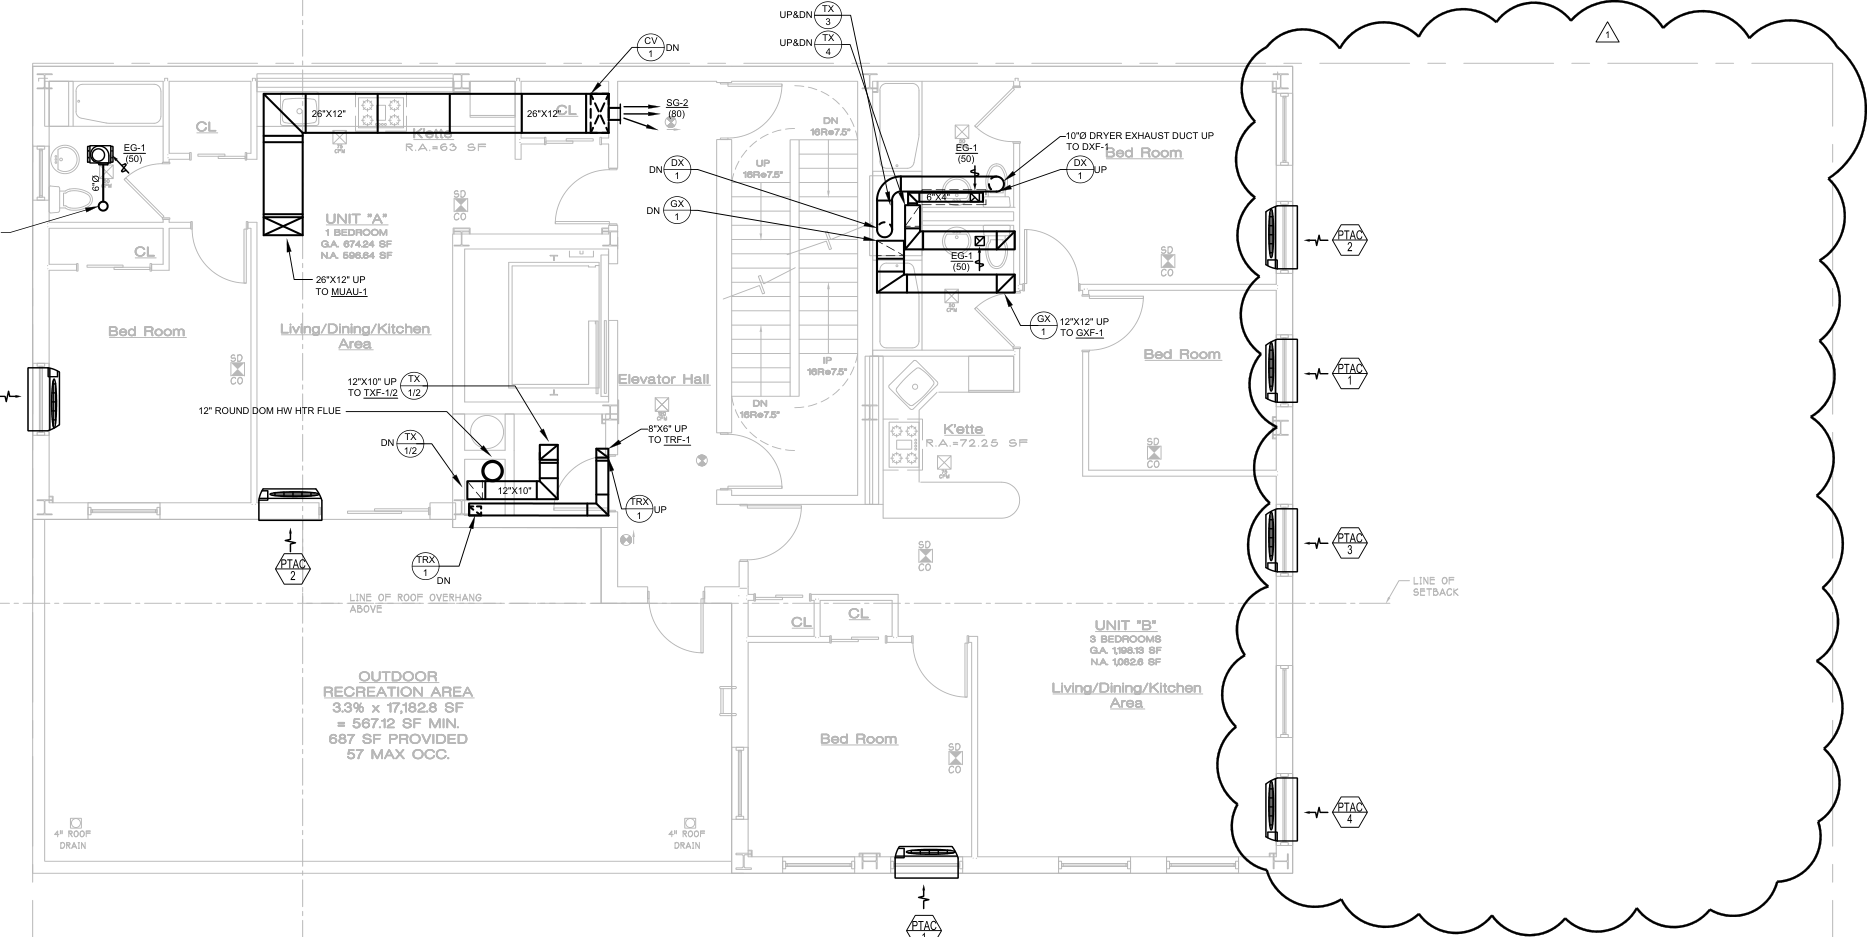

In [152]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_52.png")

cv2_imshow(img)

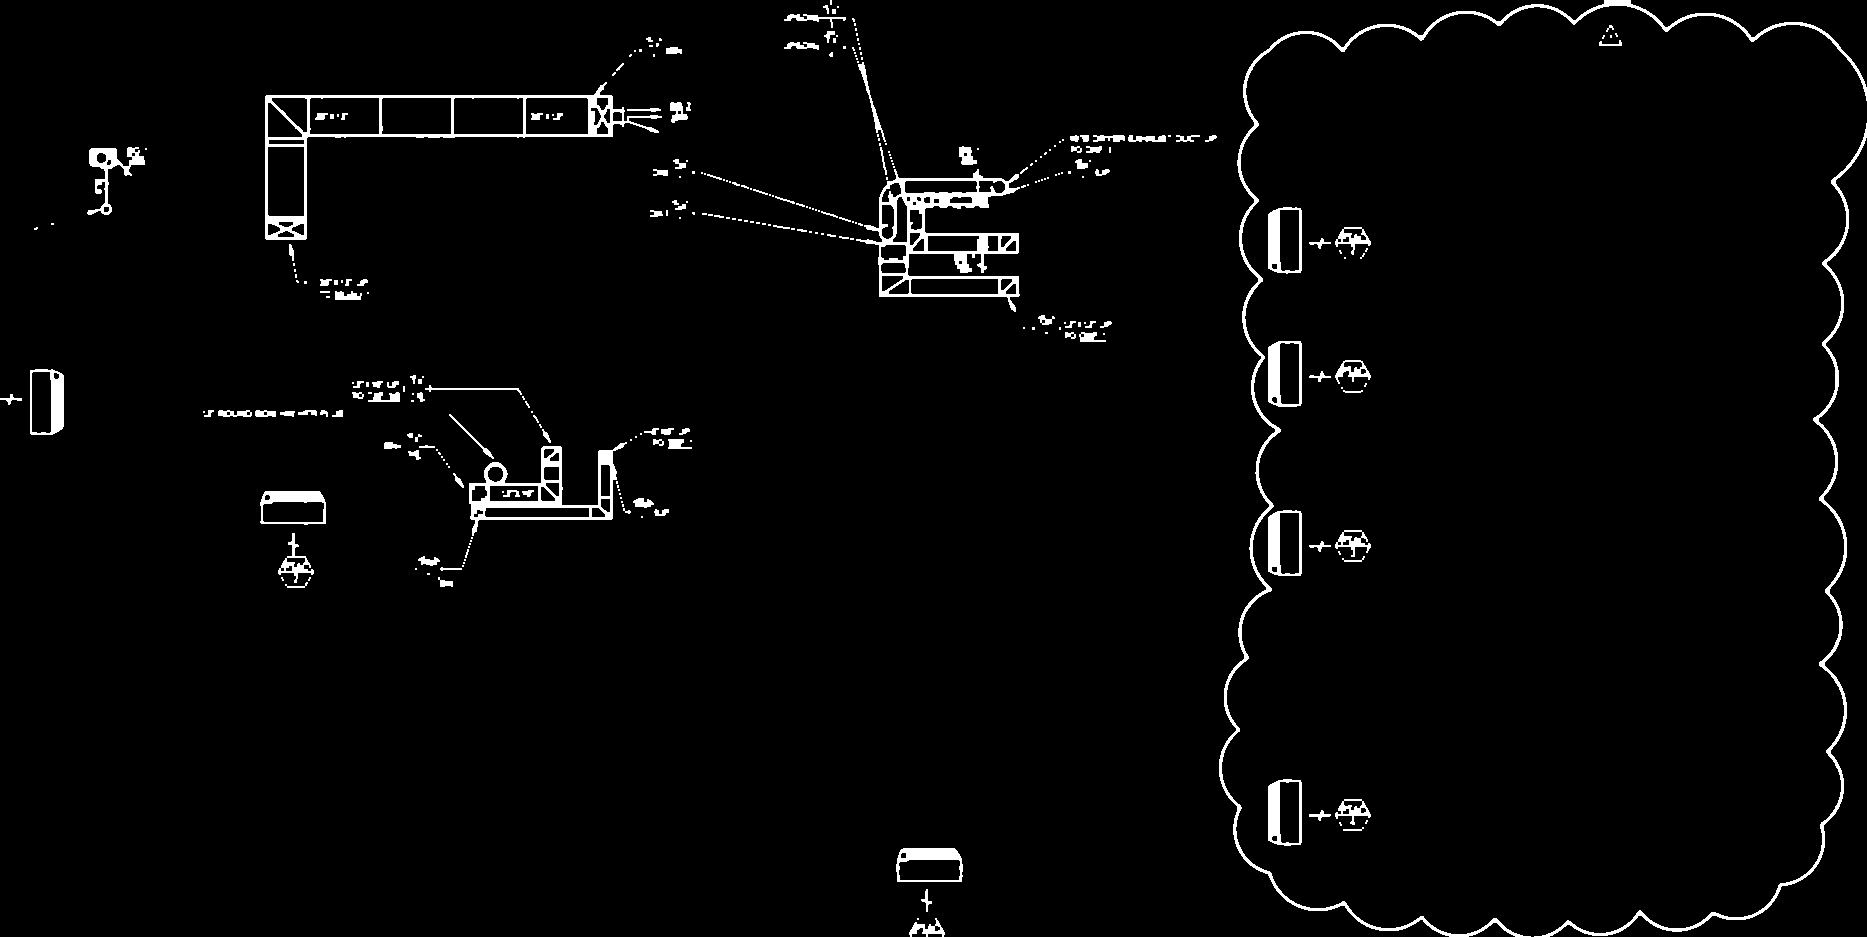

In [153]:
def preprocess_image(img):
    if len(img.shape) == 3:  # Color image with 3 channels
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:  # Image is already grayscale
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((2,2), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    kernel_erosion = np.ones((2,2), np.uint8)
    eroded = cv2.erode(closed, kernel_erosion, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

In [154]:
# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct Going Up v2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct Going Up.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png'
]

template_names = [
    'return_duct', 'return_duct', 'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend'
]

# Load and preprocess templates
templates = [preprocess_image(cv2.imread(path, 0)) for path in template_paths]

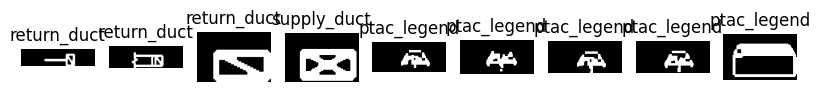

In [155]:
def preprocess_template(template_img):
    # Convert to grayscale if it's a color image
    if len(template_img.shape) == 3:  # Color image with 3 channels
        gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    else:  # Image is already grayscale
        gray = template_img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    # Apply binary thresholding without inversion
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    # Morphological operations to refine details
    kernel = np.ones((2, 2), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
    kernel_erosion = np.ones((2, 2), np.uint8)
    eroded = cv2.erode(closed, kernel_erosion, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    return dilated

# Preprocess all templates
preprocessed_templates = [preprocess_template(t) if t is not None else None for t in templates]

# Display the binary preprocessed templates
plt.figure(figsize=(10, 6))
for i, template in enumerate(preprocessed_templates):
    plt.subplot(1, len(preprocessed_templates), i + 1)
    plt.imshow(template, cmap='gray')
    plt.title(f"{template_names[i]}")
    plt.axis('off')

plt.show()

No keypoints detected in template return_duct.
No keypoints detected in template return_duct.
No keypoints detected in template return_duct.
Keypoints detected in template supply_duct at scale 0.8.
Keypoints detected in template ptac_legend at scale 0.8.
Keypoints detected in template ptac_legend at scale 0.8.
Keypoints detected in template ptac_legend at scale 0.8.
Keypoints detected in template ptac_legend at scale 0.8.
Keypoints detected in template ptac_legend at scale 0.8.


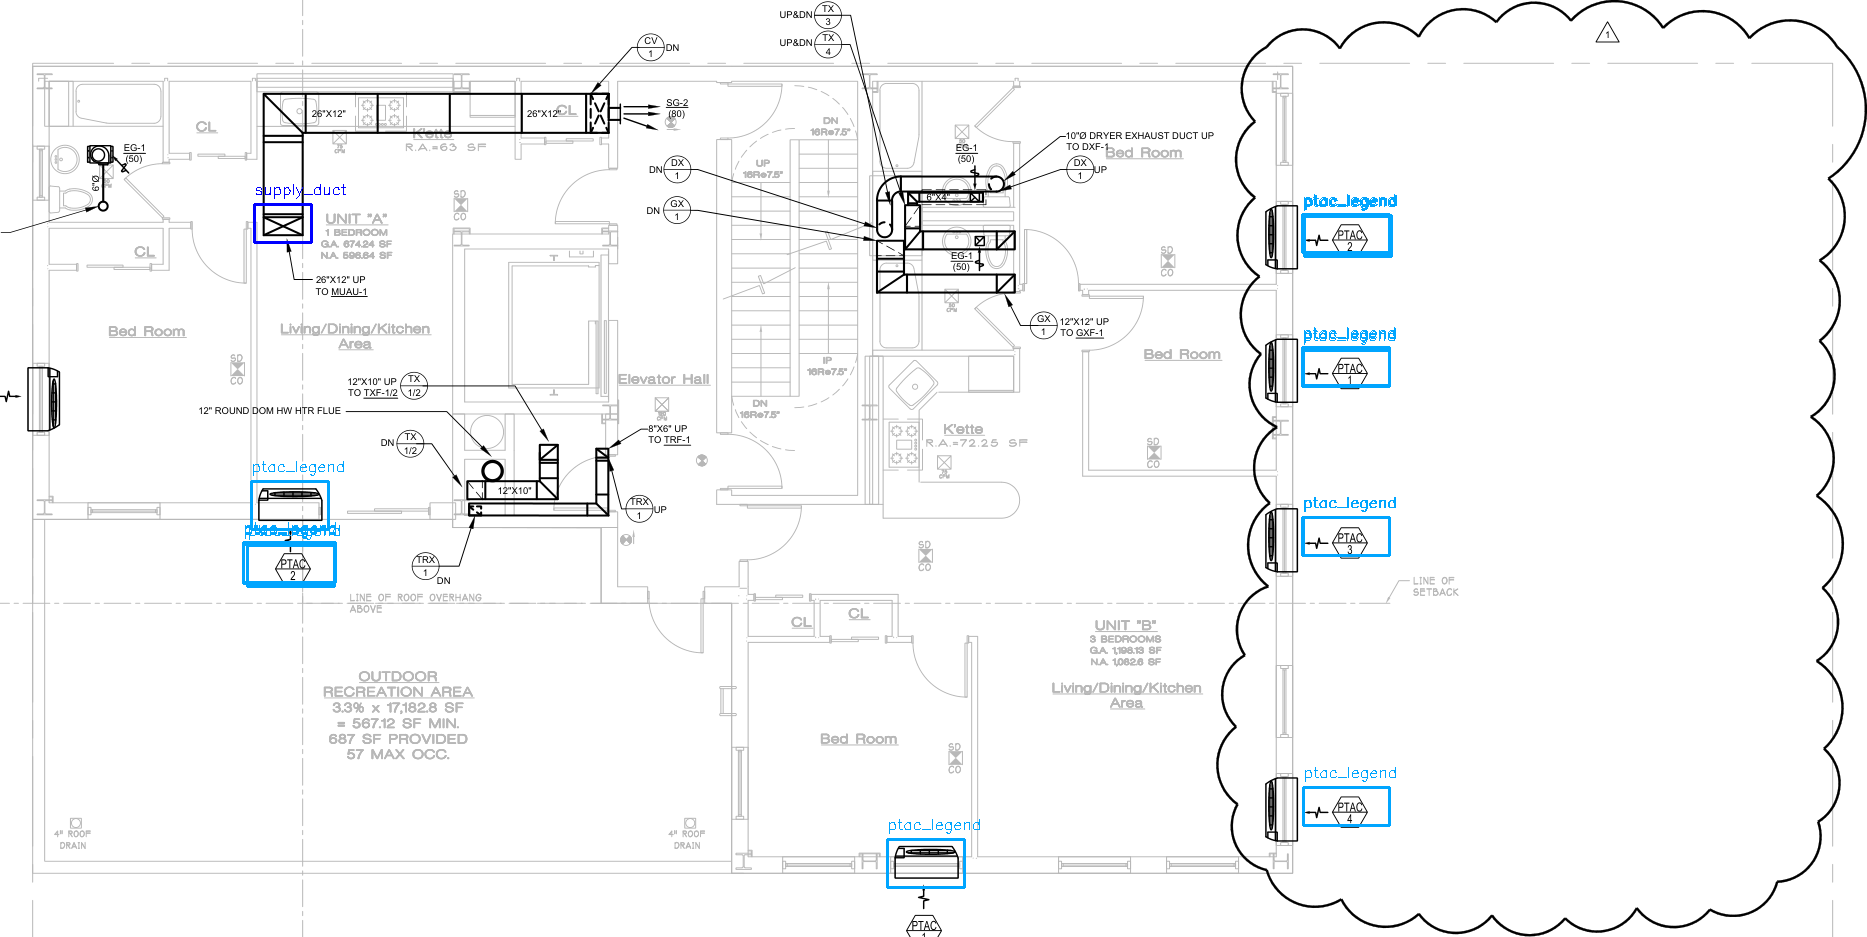

In [156]:
from imutils.object_detection import non_max_suppression

# Set different scales for multi-scale matching
scales = [1.0, 0.95, 0.9, 0.85, 0.8]

# Define the threshold value
threshold = 0.7

# Define template colors for drawing
template_colors = {
    'return_duct': (0, 0, 255),         # Blue
    'supply_duct': (255, 0, 0),         # Red
    'ptac_legend': (255, 165, 0)        # Orange
}

# Loop through each template with specified colors
for template, template_name in zip(preprocessed_templates, template_names):
    if template is None:
        print(f"No keypoints detected in template {template_name}.")
        continue

    keypoints_detected = False  # Flag to check if any keypoints are detected
    rects = []  # Store rectangles for NMS

    for scale in scales:
        # Resize the template to match different scales
        scaled_template = cv2.resize(template, (0, 0), fx=scale, fy=scale)
        w, h = scaled_template.shape[::-1]

        # Perform template matching on the preprocessed image
        result = cv2.matchTemplate(dilated, scaled_template, cv2.TM_CCOEFF_NORMED)

        # Find all locations in the result map where matched values exceed the threshold
        (yCoords, xCoords) = np.where(result >= threshold)

        # Add bounding boxes for each match
        for (x, y) in zip(xCoords, yCoords):
            rects.append((x, y, x + w, y + h))

    # Apply non-maxima suppression to remove overlapping bounding boxes
    pick = non_max_suppression(np.array(rects))

    # Check if any matches were found and draw them on the original image
    color = template_colors.get(template_name, (0, 255, 0))  # Default to green if color not found
    if len(pick) > 0:
        keypoints_detected = True
        print(f"Keypoints detected in template {template_name} at scale {scale}.")

        # Draw the final bounding boxes after NMS
        for (startX, startY, endX, endY) in pick:
            cv2.rectangle(img, (startX, startY), (endX, endY), color, 2)
            cv2.putText(img, template_name, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    if not keypoints_detected:
        print(f"No keypoints detected in template {template_name}.")

# Display the final image with detected features
cv2_imshow(img)

If legends cannot be detected via matchTemplate, we can try to use SIFT instead